# Práctica 1: Identificando Variables Relevantes

---

Practica: Identificando variables relevantes para el análisis

1.- Cargar Dataset  y explorar  la estructura general
2.- Detectar valores faltantes (missing), en columnas clave para el analisis
3.- Ver la diversidad de valores con cardinalidad

In [ ]:
import pandas as pd
df = pd.read_csv("../datasets_newtrack/everpeak_retail.csv")


Análisis Exploratorio de Datos (EDA)
proceso de conocer EL dataset antes de hacer cualquier análisis profundo.
El primer paso siempre es entender qué columnas existen, qué tipo de datos contienen y cuántos valores no nulos trae cada una.
    Esto  ayuda a saber qué partes del dataset se pueden analizar de inmediato y cuáles necesitan más trabajo:
     primer vistaso con funcion head() é info()

In [ ]:
df.head()

,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age
0,1,2024-02-02,2616,Sports,269,50,13385,credit_card,New York,NY,66.0
1,2,2024-10-10,1736,Grocery,66,0,660,debit_card,Los Angeles,CA,24.0
2,3,2024-08-27,2543,Sports,267,0,5073,credit_card,Chicago,IL,23.0
3,4,2024-06-09,2252,Toys,114,125,14290,credit_card,New York,NY,70.0
4,5,2024-06-07,1583,Fashion,729,16,11754,credit_card,Houston,TX,75.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5008 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5008 non-null   int64  
 3   product_category  5008 non-null   object 
 4   price             5008 non-null   int64  
 5   quantity          5008 non-null   int64  
 6   order_value       5008 non-null   int64  
 7   payment_method    5008 non-null   object 
 8   city              4908 non-null   object 
 9   state             4908 non-null   object 
 10  customer_age      4858 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 430.5+ KB


Conteo de valores faltantes por columna
Objetivo: Contar cuántos valores faltantes tiene cada variable de segmentación y ubicación, usando sumas, no porcentajes.

In [ ]:
#Crea una variable distinta por columna.
payment_missing = df["payment_method"].isna().sum()
city_missing = df["city"].isna().sum()
state_missing = df["state"].isna().sum()

In [ ]:
print("payment_method missing:", payment_missing)
print("city missing:", city_missing)
print("state missing:", state_missing)

payment_method missing: 0
city missing: 100
state missing: 100


revision y validacion de fechas sospechosas y montos extremos
Objetivo: Medir cuántos registros tienen fechas sospechosas y montos anormalmente altos.

In [ ]:
# estandarizamos  formato a la columna  con fusion to.datetime() y tratamos los errores  como valores  faltantes
df["order_date"] = pd.to_datetime(df["order_date"],errors="coerce")

In [ ]:
#creamos flags para determinar, calcular  y sumar los valores nulos y/o faltantes solo para el periodo 2026, ya que el data set cuenta con años anteriores
#para objeto de estudio solo  se toman  del periodo 2026
invalid_year_2026_count = (df["order_date"].dt.year==2026).sum()
missing_order_date_count = df["order_date"].isna().sum()
print("order_date año 2026:", invalid_year_2026_count)
print("order_date missing:", missing_order_date_count)

order_date año 2026: 15
order_date missing: 8


Cardinalidad en columnas de cliente
Objetivo: Calcular la cardinalidad de columnas clave para entender si son IDs, categorías o variables poco útiles.

In [ ]:
# nuevamente creamos flags  para conservar la informacion original
customer_id_unicos = df["customer_id"].nunique()
payment_unicos = df["payment_method"].nunique()
city_unicos =  df["city"].nunique()
state_unicos = df["state"].nunique()

print("customer_id nunique:", customer_id_unicos)
print("payment_method nunique:", payment_unicos)
print("city nunique:", city_unicos)
print("state nunique:", state_unicos)

customer_id nunique: 1829
payment_method nunique: 4
city nunique: 10
state nunique: 9


resumen  En está lección aprendimos a usar un conjunto pequeño de funciones de pandas para hacer un diagnóstico rápido de calidad de datos.

# Práctica 2: Manejo de Valores Ausentes e Inválidos

---

En esta lección aprendimos los fundamentos necesarios para diagnosticar y manejar valores faltantes e inválidos en un dataset real como everpeak_retail.

1.- Detectar patrones de missingness por grupo

Objetivo: Evaluar si el missing de city depende de alguna variable del negocio.
     esto con el fin de poder definir  si el patrón parece MCAR, MAR o MNAR.

In [ ]:
import pandas as pd
df = pd.read_csv("Desktop/datasets_newtrack/everpeak_retail.csv")

missing_city_by_pay = df["city"].isna().groupby(df["payment_method"]).mean()*100

print(missing_city_by_pay)

payment_method
cash           2.010050
credit_card    2.151714
debit_card     2.130045
paypal         1.531915
Name: city, dtype: float64


resumen: porcentaje de  datos faltantes  en columna "city" que tiene los distintos metodos de pago., la ralacion es  MCAR  ya que no hay relacion entre  el metodo de pago con la ciudad.

2.- Comparar impacto entre drop e imputación

Objetivo: Medir cómo cambia la métrica cuando imputas o eliminas datos.

In [ ]:
before = df["order_value"].dropna().mean()
df["order_value_imputed"] = df["order_value"].fillna(df["order_value"].median())
after = df["order_value_imputed"].mean()

print(before)
print(after)

10071.564696485622
10071.564696485622


resumen: se crean  2  flags, before y after, before, se eliminan los NaN y se calcula la media. esto para ser  un dato a comparar  con after, que es la sustitucion de los NaN con la media.
la comparativa muestra que exixte un minimo de variacion. el proceso se realiza, para valdar que si es recoemntable dejar o quitar los las filas NaN

3.- Comparar  3 versiones del mismo dato

Objetivo: Comparar tres versiones de una columna numérica para decidir la estrategia final.

In [ ]:
before = df["customer_age"].mean() # Tu código aquí

# Creamos "customer_age_med"
df["customer_age_med"] = df["customer_age"].fillna(df["customer_age"].median())# Tu código aquí
after_med = df["customer_age_med"].mean()# calcula la media aquí

# Creamos "customer_age_mean"
df["customer_age_mean"] = df["customer_age"].fillna(df["customer_age"].mean()) # Tu código aquí
after_mean = df["customer_age_mean"].mean()# calcula la media aquí

print(before)
print(after_med)
print(after_mean)

43.72869493618773
43.88658146964856
43.728694936187736


para temas de ejercicio  se realiza una comparativa en  columna "customer_age" y validamos la diferencia entre  before = media, after mediana = sustitucion de NaN con mediana  y after media = la sustitucion de NaN con media
se hace la comparativo, ya que la median es más estable si existen outliers y la media tiende a distorcionar en  caso de existencia de outliers

# Práctica 3: Creación de Funciones y Bucles

---

In [ ]:
import pandas as pd
df = pd.read_csv('../datasets_newtrack/everpeak_retail.csv')


1. Convertir a numérico múltiples columnas
   
creacion de funcion y bucle   interno  que permita automatizar  la conversion numerica en las  columas determinadas (price, quantity y order_value,) esto con la finalidad de  dar el correcto formato al tipo de dato el cual es "int64"

In [ ]:

def convertir_columnas_numericas(df, columnas):
    for col in columnas:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

columnas_numericas = ["price", "quantity", "order_value"]# <-- completa aquí


df = convertir_columnas_numericas(df, columnas_numericas) # <-- completa aquí

# 3. Revisar resultado
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5008 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5008 non-null   int64  
 3   product_category  5008 non-null   object 
 4   price             5008 non-null   int64  
 5   quantity          5008 non-null   int64  
 6   order_value       5008 non-null   int64  
 7   payment_method    5008 non-null   object 
 8   city              4908 non-null   object 
 9   state             4908 non-null   object 
 10  customer_age      4858 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 430.5+ KB


2. Extender la lista
    Objetivo: Demostrar la escalabilidad del enfoque: agregar una nueva columna y aplicar la misma función sin reescribir código.
   se anexa a  "columnas_numericas"  la columna  "customer_id", esto aplicando el metodo  .append()

In [ ]:


columnas_numericas.append("customer_id")


df = convertir_columnas_numericas(df, columnas_numericas)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5008 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5008 non-null   int64  
 3   product_category  5008 non-null   object 
 4   price             5008 non-null   int64  
 5   quantity          5008 non-null   int64  
 6   order_value       5008 non-null   int64  
 7   payment_method    5008 non-null   object 
 8   city              4908 non-null   object 
 9   state             4908 non-null   object 
 10  customer_age      4858 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 430.5+ KB


3. Limpia múltiples columnas de texto con un loop. Objetivo: Crear una función que limpie varias columnas categóricas al mismo tiempo usando: una lista de columnas y un loop, la transformacion  con metodo .str.strp() alas comlumna "product_category", "city" y "state" (ya que esta  elimna espacion en blanco y caracteres "sobrantes")


In [ ]:
def step_strip_text(df):
    columnas = ["product_category", "city", "state"]#  Definir las columnas categóricas

    # Loop para aplicar strip() a cada columna
    for col in columnas:
        df[col] = df[col].str.strip()# <-- completa aquí

    # Regresar DF limpio
    return df

# Ejecutar para probar
df = step_strip_text(df)
print(df.head())

   order_id  order_date  customer_id product_category  price  quantity  \
0         1  2024-02-02         2616           Sports    269        50   
1         2  2024-10-10         1736          Grocery     66         0   
2         3  2024-08-27         2543           Sports    267         0   
3         4  2024-06-09         2252             Toys    114       125   
4         5  2024-06-07         1583          Fashion    729        16   

   order_value payment_method         city state  customer_age  
0        13385    credit_card     New York    NY          66.0  
1          660     debit_card  Los Angeles    CA          24.0  
2         5073    credit_card      Chicago    IL          23.0  
3        14290    credit_card     New York    NY          70.0  
4        11754    credit_card      Houston    TX          75.0  


# Práctica 4: Creación de un Pipeline de Limpieza

---

1. Función para reemplazar Sentinels;
    Objetivo: : Crear una función básica que reemplace valores sentinels por NaN directamente en una columna específica.
        para el caso de estudio la columna sera  "customer_age"

In [ ]:
def reemplazar_sentinels (df, sentinels): # tu código aquí
    df["customer_age"]= df["customer_age"].replace(sentinels, pd.NA)
    return df

# --------------------------------------------------------------------
# Importar librería y leer datos
import pandas as pd
df = pd.read_csv("../datasets_newtrack/everpeak_retail.csv")

# observar valores ausentes iniciales
print("Valores ausentes", df["customer_age"].isna().sum())

# Fijar valores a corregir
valores_erroneos = [-999, 999, 0, -1]

# Aplicar función, guardar resultados y observar cambios
df = reemplazar_sentinels(df, valores_erroneos) # tu código aquí
print("Valores ausentes", df["customer_age"].isna().sum())

Valores ausentes 150
Valores ausentes 175


se logran remplazar  los sentinels a NaN, por ello el aumento de  "ausentes"

2.Mejorar función para reemplazar Sentinels
Objetivo: Mejorar la función anterior para que pueda trabajar con múltiples columnas numéricas usando un bucle. para caso de estudio se aplica a las columnas  "customer_age" y "price" ya que el bucle nos permite aplicarlo a listas de columnas

In [ ]:
def reemplazar_sentinels(df, sentinels, numeric_cols):
    for col in numeric_cols:
        df[col]=df[col].replace(sentinels, pd.NA)
    return df

# --------------------------------------------------------------------
# Importar librería y leer datos
import pandas as pd
df = pd.read_csv("../datasets_newtrack/everpeak_retail.csv")

# observar valores ausentes iniciales
print("Valores ausentes iniciales:")
print(df[["customer_age", "price"]].isna().sum())

# Fijar valores a corregir y columnas
valores_erroneos = [-999, 999, 0, -1]
columnas_numericas = ["customer_age", "price"]

# Aplicar función y observar cambios
df = reemplazar_sentinels(df, valores_erroneos, columnas_numericas)
print("\nValores ausentes después:")
print(df[["customer_age", "price"]].isna().sum())

Valores ausentes iniciales:
customer_age    150
price             0
dtype: int64

Valores ausentes después:
customer_age    175
price             2
dtype: int64


la implementacion del bucle en la funcion  de remplazo de sentinels, nos permitio  realizar  la limpieza  varias columnas

3.-Función para rellenar ausentes
Objetivo: Crear una función que convierta columnas a tipo numérico y rellene valores ausentes con el promedio. esto con el fin de "elimnar los valores ausentes en las  columnas de estudio"

In [ ]:
def rellenar_ausentes(df, cols_fill):
   for col in cols_fill: # bucle para recorrer columnas
       df[col]= pd.to_numeric(df[col], errors="coerce")
       df[col].fillna(df[col].mean(), inplace=True)
   return df

# --------------------------------------------------------------------
# Importar librería y leer datos
import pandas as pd
df = pd.read_csv("../datasets_newtrack/everpeak_retail.csv")

# observar valores ausentes iniciales
print("Valores ausentes iniciales:")
print(df[["customer_age", "price"]].isna().sum())

# Definir columnas a rellenar
columnas_rellenar = ["customer_age", "price"]

# Aplicar función y observar cambios
df = rellenar_ausentes(df, columnas_rellenar)
print("\nValores ausentes después:")
print(df[["customer_age", "price"]].isna().sum())

Valores ausentes iniciales:
customer_age    150
price             0
dtype: int64

Valores ausentes después:
customer_age    0
price           0
dtype: int64


C:\Users\vmlpr\AppData\Local\Temp\ipykernel_16848\2630121030.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


4. Crear Pipeline de limpieza
    Objetivo: Crear una función pipeline que orqueste todas las funciones de limpieza en el orden correcto.
    Usemos las funciones que hicimos en los ejercicios anteriores y agreguemos una nueva.

In [ ]:
def reemplazar_sentinels(df, sentinels, numeric_cols):
    for col in numeric_cols:
        df[col] = df[col].replace(sentinels, pd.NA)
    return df

def rellenar_ausentes(df, cols_fill):
    for col in cols_fill:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col].fillna(df[col].mean(), inplace=True)
    return df

# Crear función pipeline
def limpiar_df(df):
    valores_erroneos = [-999, 999, 0, -1]# tu código aquí: definir valores_erroneos
    columnas_numericas = ["customer_age", "price"]# tu código aquí: definir columnas_numericas

    df = reemplazar_sentinels(df, valores_erroneos, columnas_numericas)# tu código aquí: aplicar reemplazar_sentinels
    df = rellenar_ausentes(df, columnas_numericas)# tu código aquí: aplicar rellenar_ausentes

    return df

# --------------------------------------------------------------------
# Importar librería y leer datos
import pandas as pd
df = pd.read_csv("../datasets_newtrack/everpeak_retail.csv")

# observar valores ausentes iniciales
print("Valores ausentes iniciales:")
print(df[["customer_age", "price"]].isna().sum())

# Aplicar pipeline completo
df = limpiar_df(df) # tu código aquí
print("\nValores ausentes después del pipeline:")
print(df[["customer_age", "price"]].isna().sum())

Valores ausentes iniciales:
customer_age    150
price             0
dtype: int64

Valores ausentes después del pipeline:
customer_age    0
price           0
dtype: int64


C:\Users\vmlpr\AppData\Local\Temp\ipykernel_16848\1408678445.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


# Pipeline Intermedio: Creación del Pipeline

---

Piperline   realizado en  en las sesiones de aprendisaje, el cual es caso de estudio
funcion del piperline, automatizar  la  limpieza escalable   

creacion de funciones iniciales, remplazar sentinels, crear flags e imputar segun diagnostico

In [ ]:
def reemplazar_sentinels_global(df, numeric_cols, text_cols):
    numeric_sentinels = [-999, 999]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].replace(numeric_sentinels, pd.NA)

    text_sentinels = ["?"]
    for col in text_cols:
        df[col] = df[col].replace(text_sentinels, "unknown")
    return df

In [ ]:
def crear_flags(df, flags_cols):
    for col in flags_cols:
        nombre_flag = col + "_missing_flag"
        df[nombre_flag] = df[col].isna().astype(int)
    return df

In [ ]:
# crear función para imputar ausentes
def imputar_segun_diagnostico(df, median_fill_cols, fill_unknown_cols, date_drop_cols):
    # rellenar con la mediana en columnas numéricas
    for col in median_fill_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        med = df[col].median()
        df[col] = df[col].fillna(med)

    # rellenar con texto "unknown" en columnas categóricas
    for col in fill_unknown_cols:
        df[col] = df[col].fillna("unknown")

    # eliminar registros con valores ausentes en columnas tipo fecha
    for col in date_drop_cols:
        df[col] = pd.to_datetime(df[col], errors="coerce")
        df = df.dropna(subset=[col]).reset_index(drop=True)
    return df

creacion de  funcion "clean_data" la cual cordina las funciones  anteriores para el proceso escalable de limpieza

In [ ]:
def clean_data(df,numeric_cols, text_cols, flags_cols,
    median_fill_cols, fill_unknown_cols, date_drop_cols):

    # Sentinels: reemplazar marcadores inválidos por NaN
    df = reemplazar_sentinels_global(df, numeric_cols, text_cols)

    # Flags: crear banderas antes de imputar
    df = crear_flags(df, flags_cols)

    # Imputaciones / drops finales
    df = imputar_segun_diagnostico(df,median_fill_cols,fill_unknown_cols,date_drop_cols)
    return df

In [ ]:

# DataFrame a procesar: Everpeak
import pandas as pd
df = pd.read_csv("../datasets_newtrack/everpeak_retail.csv")

# Listas de columnas - incluir columnas según las necesidades del dataset

# columnas a procesar del dataset EverPeak
## columnas función 1: reemplazar_sentinels
columnas_numericas = ["customer_age"]
columnas_texto = ["product_category"]

## columnas función 2: crear_flags
columnas_flags = ["customer_age", "city", "state"]

## columnas función 3: imputar_segun_diagnostico
cols_imputar_mediana = ["customer_age"]
cols_imputar_unknown = ["city", "state"]
cols_imputar_fecha = ["order_date"]

# aplicar función y guardar resultado en df_clean
df_clean = clean_data(df, columnas_numericas, columnas_texto, columnas_flags,
    cols_imputar_mediana, cols_imputar_unknown, cols_imputar_fecha)

# guardar df_clean en un CSV nuevo
df_clean.to_csv("../datasets_newtrack/everpeak_clean.csv", index=False)

# Práctica 5: Medidas Estadísticas en Columnas Numéricas

---

Después de limpiar el dataset, el equipo quiere entender cómo se distribuyen los datos para tomar decisiones informadas.

En esta parte del caso de negocios, surgen las preguntas:

¿Los clientes realmente gastan “en promedio” lo que creemos?
¿Ese promedio representa al cliente típico o a unos pocos casos raros?
Para responder necesitas dominar las medidas estadísticas descriptivas, un conjunto de herramientas que permiten resumir miles de registros en números fáciles de interpretar.

1. Resumen numérico
Objetivo: El equipo de Inteligencia Comercial necesita una visión rápida del desempeño de las categorías Fashion y Sports para entender su situación actual y detectar posibles anomalías en los datos.
para ello  creamos un resumen estadistico  el cual nos permite visualizar  si existen sesgos
tomando como referencia, mediana y la desviacion estandar, y asi la std es muy alta y/ o  alejada de la mediana, indica posibles outlaiers

In [ ]:
import pandas as pd

df = pd.read_csv('../datasets_newtrack/everpeak_clean.csv')

# Crear dataframes para cada categoría
df_fashion = df[df["product_category"]=='Fashion']
df_sports = df[df['product_category']=="Sports"]

# --- Resumen de columnas numéricas con describe()
columnas_numericas = ['order_value', 'customer_age', 'price', 'quantity']

print('Resumen estadístico de la categoría Fashion')
print(df_fashion[columnas_numericas].describe())

print()#Salto de Línea
print('Resumen estadístico de la categoría Sports')
print(df_sports[columnas_numericas].describe())

Resumen estadístico de la categoría Fashion
         order_value  customer_age         price    quantity
count     739.000000    739.000000    739.000000  739.000000
mean     8745.139378     48.066306    585.863329   15.185386
std     10318.954880     18.083657    655.641761   30.712929
min       122.000000     18.000000     25.000000    0.000000
25%      2913.000000     32.000000    274.500000    0.000000
50%      8115.000000     47.000000    457.000000    0.000000
75%     12527.000000     64.000000    680.000000   21.000000
max    224884.000000     80.000000  11836.000000  284.000000

Resumen estadístico de la categoría Sports
        order_value  customer_age        price    quantity
count    702.000000    702.000000   702.000000  702.000000
mean   10365.264957     49.742165   839.692308   12.905983
std     8820.536231     17.437736   848.292770   26.463546
min      195.000000     18.000000    47.000000    0.000000
25%     4308.750000     36.000000   347.000000    0.000000
50%    10

2: Promedio vs Mediana del gasto (Grocery)
    Objetivo: El equipo quiere entender si el gasto típico de los clientes que compran productos de supermercado está siendo    afectado por outliers. para ello se  compara la media y la mediana de la columna order_value para evaluar si hay valores    extremos influyendo en el análisis.

In [ ]:
df_grocery = df[df['product_category']== "Grocery"] # Escribe tu código aquí]

# Calcular media y mediana del gasto
promedio = df_grocery["order_value"].mean()# Escribe tu código aquí
mediana = df_grocery["order_value"].median()# Escribe tu código aquí

# Mostrar resultados
print("Promedio del gasto en Grocery:", promedio)
print("Mediana del gasto en Grocery:", mediana)

# Interpretación según comparación de media y mediana
print("El promedio está afectado por outliers o valores atípicos en Grocery.")

Promedio del gasto en Grocery: 6943.137426900585
Mediana del gasto en Grocery: 4131.0
El promedio está afectado por outliers o valores atípicos en Grocery.


3.- Promedio vs Mediana quantity
Objetivo: El equipo sospecha que existen outliers en la cantidad de productos comprados.

compararemos  la  media y la mediana de la columna quantity para evaluar si los valores extremos están afectando el análisis de la cantidad típica comprada por los clientes.

In [ ]:
print("Promedio de quantity: ",df['quantity'].mean())
print("Mediana de quantity: ", df['quantity'].median())
print("El promedio está afectado por los outliers o valores atípicos.")

Promedio de quantity:  21.8792
Mediana de quantity:  0.0
El promedio está afectado por los outliers o valores atípicos.


4.- Resumen numérico por ciudad
El equipo necesita una visión rápida del comportamiento de los clientes en las ciudades New York y Los Angeles, para comprender su situación actual y detectar posibles anomalías en los datos.

In [ ]:
df_ny = df[df["city"]=="New York"]
df_la = df[df["city"]=="Los Angeles"]

# --- Resumen de columnas numéricas con describe()
columnas_numericas = ['order_value', 'customer_age', 'price', 'quantity']

print('Resumen estadístico de la ciudad New York')
print(df_ny[columnas_numericas].describe())

print()#Salto de Línea
print('Resumen estadístico de la ciudad Los Angeles')
print(df_la[columnas_numericas].describe())

Resumen estadístico de la ciudad New York
         order_value  customer_age         price     quantity
count     497.000000    497.000000    497.000000   497.000000
mean    10545.410463     49.847082    741.454728    25.384306
std     13914.329615     17.507624   1105.570500    76.226789
min        58.000000     18.000000     12.000000     0.000000
25%      2862.000000     35.000000    203.000000     0.000000
50%     10682.000000     49.000000    457.000000     0.000000
75%     13327.000000     64.000000    787.000000    23.000000
max    224884.000000     80.000000  11836.000000  1258.000000

Resumen estadístico de la ciudad Los Angeles
         order_value  customer_age         price     quantity
count     510.000000    510.000000    510.000000   510.000000
mean    10449.945098     49.741176    751.674510    24.882353
std     15979.195581     17.670518   1175.722235    76.853226
min        44.000000     18.000000     13.000000     0.000000
25%      3160.500000     35.000000    202.50

recordemos que la media, es sensible a valores extremos , generando y la mediana es mas estable, podemos visualizar  posibles  outliers

# Práctica 6: Medidas Estadísticas en Columnas Categóricas

---

Medidas Estadísticas en Columnas Categóricas

Después de analizar las columnas numéricas, donde calculamos media, mediana, desviación estándar, mínimo y máximo, ahora nos enfocaremos en las columnas categóricas.

En esta parte del caso de negocios, las preguntas se vuelven más cualitativas:

¿Cuáles son las categorías más frecuentes en los productos o métodos de pago?
¿Hay alguna ciudad o estado que concentre la mayoría de los clientes?
¿Existen categorías raras o poco representadas que podrían afectar nuestros análisis?

1.- resumen categorico

Objetivo: El equipo necesita entender la distribución de los métodos de pago y las categorías de producto en Nueva York y Chicago para identificar patrones dominantes, diversidad de categorías y posibles anomalías.

In [ ]:
import pandas as pd

df = pd.read_csv('Desktop/datasets_newtrack/everpeak_clean.csv')

#  Columnas categóricas
columnas_categoricas = ['payment_method', 'product_category']

# Filtra por ciudad
df_ny = df[df["city"]== "New York"]# Escribe tu código aquí]
df_chicago = df[df["city"]== "Chicago"]# Escribe tu código aquí]

# Resumen categórico New York
print("Resumen categórico - New York")
print(df_ny[columnas_categoricas].describe())# Escribe tu código aquí)

print() # salto de línea

# Resumen categórico Chicago
print("Resumen categórico - Chicago")
print(df_chicago[columnas_categoricas].describe())

Resumen categórico - New York
       payment_method product_category
count             497              497
unique              4                8
top       credit_card             Toys
freq              271               76

Resumen categórico - Chicago
       payment_method product_category
count             482              482
unique              4                8
top       credit_card             Toys
freq              284               74


2.- Distribución completa de categorías con "value_counts()"

Objetivo: Revisar todas las categorías de una lista de columnas junto con su frecuencia absoluta y frecuencia relativa (%), para ello aplicaremos un bucle "for"  para hacer mas sencillo y practico el codigo.

In [ ]:

columnas_categoricas = ['product_category', 'payment_method', 'city', 'state']

# --- Distribución completa de columnas categóricas usando for
for col in columnas_categoricas:
    print(col)
    print("Frecuencia absoluta")
    print(df[col].value_counts())
    print("Frecuencia relativa")
    print(df[col].value_counts(normalize=True))
    print()

product_category
Frecuencia absoluta
product_category
Fashion        739
Electronics    735
Beauty         721
Toys           715
Sports         702
Grocery        684
Home           679
unknown         25
Name: count, dtype: int64
Frecuencia relativa
product_category
Fashion        0.1478
Electronics    0.1470
Beauty         0.1442
Toys           0.1430
Sports         0.1404
Grocery        0.1368
Home           0.1358
unknown        0.0050
Name: proportion, dtype: float64

payment_method
Frecuencia absoluta
payment_method
credit_card    2737
paypal         1175
debit_card      889
cash            199
Name: count, dtype: int64
Frecuencia relativa
payment_method
credit_card    0.5474
paypal         0.2350
debit_card     0.1778
cash           0.0398
Name: proportion, dtype: float64

city
Frecuencia absoluta
city
Houston          513
Seattle          513
Los Angeles      510
New York         497
Miami            493
Phoenix          491
Chicago          482
Boston           474
San Franci

3.- Resumen categórico

Objetivo: El equipo necesita entender la distribución de los métodos de pago y las ciudades asociadas a la categoría Toys, para identificar patrones dominantes, diversidad de ciudades y posibles anomalías.

In [ ]:
columnas_categoricas = ['payment_method', 'city']

# Filtra por categoría
df_toys = df[df["product_category"]=="Toys"]# Escribe tu código aquí]

# Resumen categórico Toys
print("Resumen categórico - Toys")
print(df_toys[columnas_categoricas].describe()) # Escribe tu código aquí)

Resumen categórico - Toys
       payment_method     city
count             715      715
unique              4       11
top       credit_card  Seattle
freq              383       81


4.- Distribución completa de ciudades con value_counts() (Sports)


Objetivo: Revisar todas las ciudades asociadas a la categoría Sports, mostrando su frecuencia absoluta y su frecuencia relativa para entender la distribución de ubicaciones dentro de esta categoría.

In [ ]:
df_sports = df[df["product_category"]=="Sports"]# Escribe tu código aquí]

# Distribución de city
print("Frecuencia absoluta")
print(df_sports["city"].value_counts())  # Escribe tu código aquí)
print("\nFrecuencia relativa")
print(df_sports["city"].value_counts(normalize=True)) # Escribe tu código aquí)

Frecuencia absoluta
city
San Francisco    85
Los Angeles      84
New York         74
Miami            74
Denver           68
Seattle          67
Boston           66
Chicago          60
Houston          59
Phoenix          55
unknown          10
Name: count, dtype: int64

Frecuencia relativa
city
San Francisco    0.121083
Los Angeles      0.119658
New York         0.105413
Miami            0.105413
Denver           0.096866
Seattle          0.095442
Boston           0.094017
Chicago          0.085470
Houston          0.084046
Phoenix          0.078348
unknown          0.014245
Name: proportion, dtype: float64


# Práctica 7: Visualizando Distribuciones con Histogramas

---

1.- Analizando la distribución de precios usando histogramas


Objetivo: El equipo de Inteligencia Comercial quiere entender cómo se distribuyen los precios y detectar posibles valores atípicos que puedan afectar los análisis.

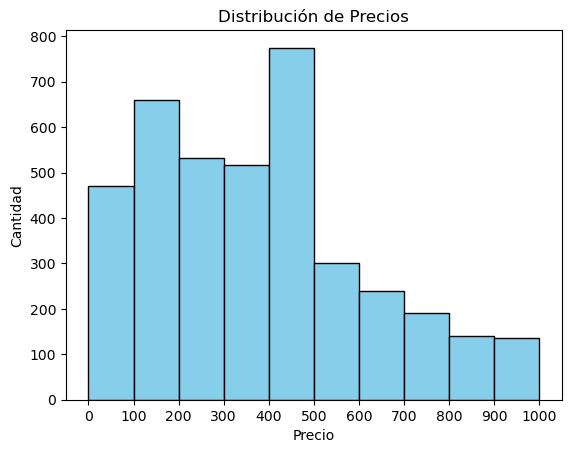

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../datasets_newtrack/everpeak_clean.csv')

# Graficar histograma
counts, bin_edges, _ = plt.hist(df["price"], bins=10, range=(0, 1000), color="skyblue", edgecolor="black")# Escribe tu código aquí

# Mostrar las marcas de los bins en el eje X
plt.xticks(bin_edges)     # Escribe tu código aquí

# Etiquetas y título del gráfico
plt.xlabel("Precio")# tu código aquí)
plt.ylabel("Cantidad")# tu código aquí)
plt.title("Distribución de Precios")# tu código aquí)
plt.show()

2.- Distribución de edades de clientes


Objetivo: El equipo quiere entender la distribución de las edades de los clientes (customer_age) para segmentar mejor las estrategias de marketing.


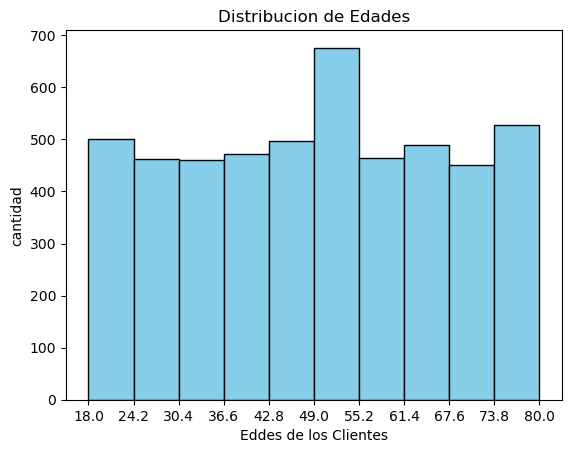

In [ ]:

# Graficar histograma
counts, bin_edges, _ = plt.hist(df["customer_age"], bins=10, color="skyblue", edgecolor="black")# tu código aquí

# Mostrar las marcas de los bins en el eje X
plt.xticks(bin_edges)# tu código aquí

# Etiquetas y título del gráfico
plt.xlabel("Eddes de los Clientes")# tu código aquí)
plt.ylabel("cantidad")# tu código aquí
plt.title("Distribucion de Edades")# tu código aquí
plt.show()

# Práctica 8: Explorando Distribuciones con Boxplots e Histogramas

---

Explorando distribuciones con Boxplots e Histogramas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../datasets_newtrack/everpeak_clean.csv')


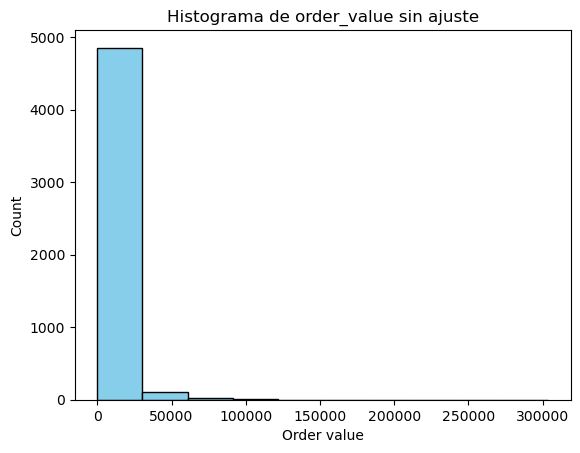

In [ ]:
plt.hist(df['order_value'], bins=10, color='skyblue', edgecolor='black')
plt.title('Histograma de order_value sin ajuste')
plt.xlabel('Order value')
plt.ylabel('Count')
plt.show()

visualizamos que el eje  "x"  se  esta "estirando" por valores atipico
revisemos  valosres con describe para  ver en donde los limites inferiores y superiores y poder visualizar los rangos  IQR

In [ ]:
df['order_value'].describe()

count      5000.000000
mean      10075.523800
std       12406.603152
min          12.000000
25%        3094.000000
50%       10341.000000
75%       13160.500000
max      303824.000000
Name: order_value, dtype: float64

EL Q3 75% suele marcar el límite superior de la mayoría de los pedidos.

por ello ajustaremos el eje "X" para poder visualizar  de forma mas detallada  la dispersion de los datos  entre  el Q1 y Q3


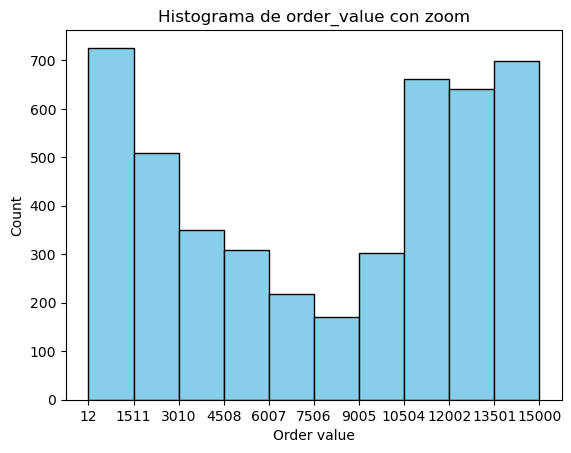

In [ ]:
counts, bin_edges, _ = plt.hist(df['order_value'], bins=10, range=(12, 15000), color='skyblue', edgecolor='black')
plt.xticks(bin_edges)
plt.title('Histograma de order_value con zoom')
plt.xlabel('Order value')
plt.ylabel('Count')
plt.show()

con un boxplot es  mas  sensillo de visualizar los  outlier

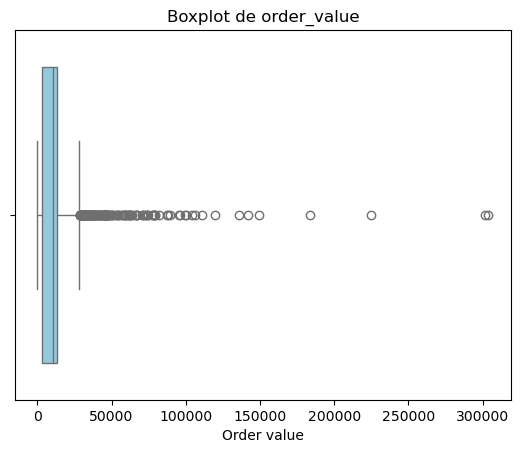

In [ ]:
sns.boxplot(x=df['order_value'], color='skyblue')
plt.title('Boxplot de order_value')
plt.xlabel('Order value')
plt.show()

practica  Analizando la distribución de precios

Objetivo: El equipo de Inteligencia Comercial quiere entender cómo se distribuyen los precios y detectar posibles valores atípicos que puedan afectar los análisis.

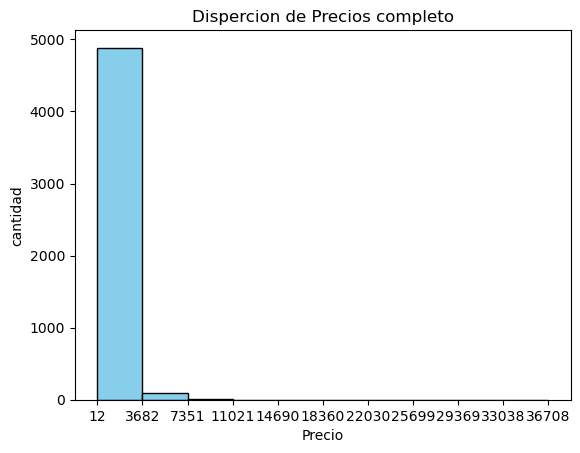

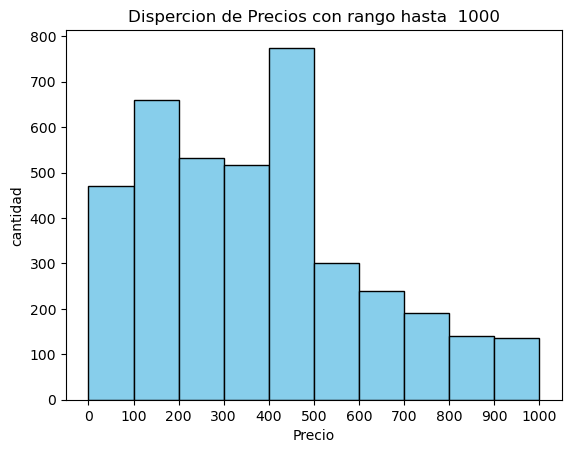

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../datasets_newtrack/everpeak_clean.csv')

# Graficar histograma
counts, bin_edges, _ = plt.hist(df["price"], bins=10, color="skyblue", edgecolor="black")
# Mostrar las marcas de los bins en el eje X
plt.xticks(bin_edges) # Escribe tu código aquí

# Etiquetas y título del gráfico
plt.xlabel("Precio")# tu código aquí)
plt.ylabel("cantidad")# tu código aquí)
plt.title("Dispercion de Precios completo")# tu código aquí)
plt.show()

print()

counts, bin_edges, _ = plt.hist(df["price"], bins=10, range=(0,1000), color="skyblue", edgecolor="black")
# Mostrar las marcas de los bins en el eje X
plt.xticks(bin_edges) # Escribe tu código aquí
plt.xlabel("Precio")# tu código aquí)
plt.ylabel("cantidad")# tu código aquí)
plt.title("Dispercion de Precios con rango hasta  1000")# tu código aquí)
plt.show()


podemos visualizar rapidamente  que los precios  se concentran en entre 400 y 500, con un sesgo a la derecha, se limito el rango hasta  1000, pero este  sego es superior, ya que sin rango  es nulo   visualizar los rangos de los precios con mayoria

2.- Explorando la dispersión de cantidades con Boxplot
Objetivo: El equipo de Inteligencia Comercial necesita analizar cómo se distribuyen las cantidades compradas (quantity) dentro de la categoría "Toys", para detectar valores extremos que podrían afectar decisiones de inventario y logística.

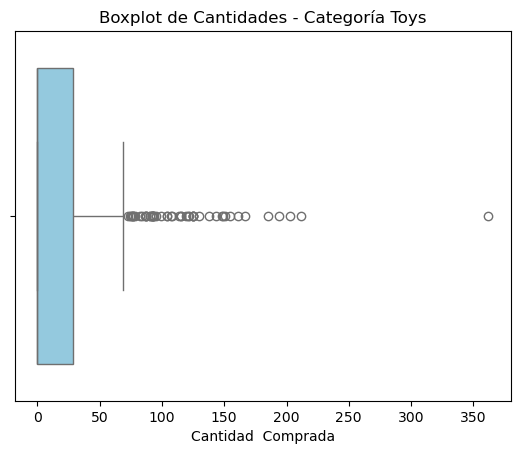

rapidamente  pemrite visulizar los outlaier y/o valores atipicos dentro de la columna, y el sesgo a la derecha ya que el IQR est pegado al Q1


In [ ]:
df_toys = df[df["product_category"] =="Toys"]    # tu código aquí

# Graficar BoxPlot
sns.boxplot(x=df_toys["quantity"], color="skyblue")

# Etiquetas y título del gráfico
plt.title("Boxplot de Cantidades - Categoría Toys")
plt.xlabel("Cantidad  Comprada")

plt.show()

print("rapidamente  pemrite visulizar los outlaier y/o valores atipicos dentro de la columna, y el sesgo a la derecha ya que el IQR est pegado al Q1")

3.- Distribución de edades de clientes

Objetivo: El equipo quiere entender la distribución de las edades de los clientes (customer_age) para segmentar mejor las estrategias de marketing.
    realizaremos un histograma para poder visualizar  la dispersion y poder identificar  el nicho de  clientes

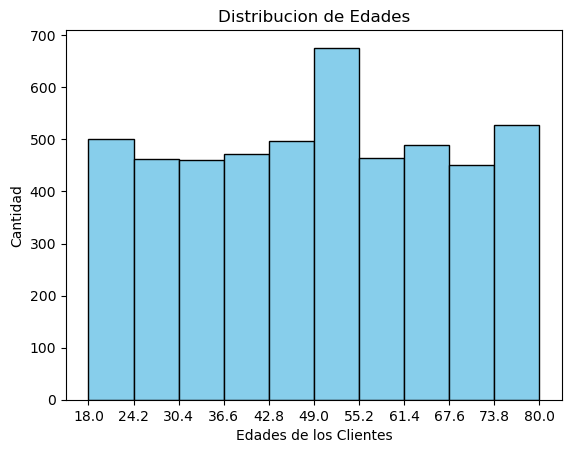

se púede visualizar que la edad con myoria de  los clientes  es de 49  a 55.20


In [ ]:
counts, bin_edges, _ = plt.hist(df["customer_age"], bins=10, color="skyblue", edgecolor="black")

# Mostrar las marcas de los bins en el eje X
plt.xticks(bin_edges)


# Etiquetas y título del gráfico
plt.xlabel("Edades de los Clientes")
plt.ylabel("Cantidad")
plt.title("Distribucion de Edades")
plt.show()

print("se púede visualizar que la edad con myoria de  los clientes  es de 49  a 55.20")

4.-Boxplot del valor total de pedidos

Objetivo: El equipo necesita analizar cuánto gastan los clientes en las categorías “Fashion” y “Sports”, evaluando la dispersión del order_value y detectando posibles outliers que puedan afectar decisiones de negocio.

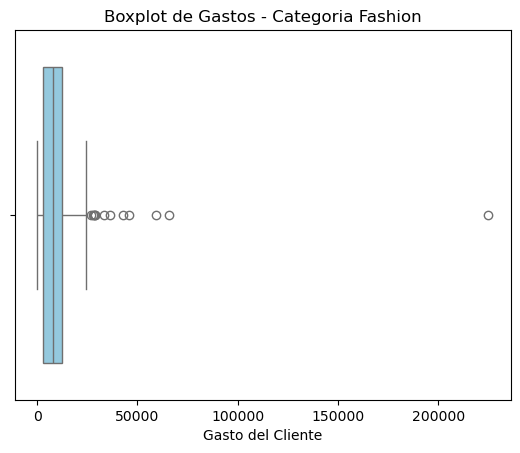

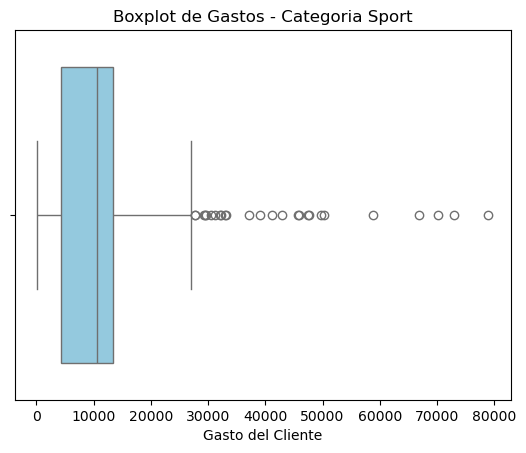

In [ ]:
df_fashion = df[df["product_category"] =="Fashion"]
df_sports = df[df["product_category"] =="Sports"]

# BoxPlot Categoría Fashion
sns.boxplot(x=df_fashion["order_value"], color="skyblue")# tu código aquí)
plt.xlabel("Gasto del Cliente")
plt.title("Boxplot de Gastos - Categoria Fashion")
plt.show()

# BoxPlot Categoría Sports
sns.boxplot(x=df_sports["order_value"], color="skyblue")
plt.xlabel("Gasto del Cliente")
plt.title("Boxplot de Gastos - Categoria Sport")
plt.show()

# Práctica 9: Identificando Valores Atípicos

---

Identificando valores atípicos con reglas estadísticas

El equipo de Estrategia e Integración de EverPeak ya entendió que las distribuciones del dataset presentan colas largas, valores extremos y patrones que afectan el promedio y la interpretación del comportamiento del cliente

Pero ahora surge una pregunta clave para avanzar en el análisis:

👉 ¿Cómo detectar y manejar los outliers o valores atípicos?

1 — Detectar outliers con IQR

Objetivo: Identificar outliers en order_value con IQR.

In [ ]:
import pandas as pd
df = pd.read_csv("../datasets_newtrack/everpeak_clean.csv")

print("revision a columna order_value, esto para entender los Q")
df["order_value"].describe()


revision a columna order_value, esto para entender los Q


count      5000.000000
mean      10075.523800
std       12406.603152
min          12.000000
25%        3094.000000
50%       10341.000000
75%       13160.500000
max      303824.000000
Name: order_value, dtype: float64

In [ ]:
# calcular Q1, Q3 e IQR
Q1 = df["order_value"].quantile(0.25)
Q3 = df["order_value"].quantile(0.75)
IQR = Q3 - Q1

# calcular límite inferior y superior
limite_inferior = Q1-1.5*IQR
limite_superior = Q3+1.5*IQR

# Mostrar resultados
print('Primer cuartil: ', Q1)
print('Tercer cuartil: ', Q3)
print('IQR: ', IQR)

print("\nRegistros abajo del límite inferior")
print(df[df["order_value"]<limite_inferior].count()) # en la practica original, en el print no se incluye el metodo count, pero este lo inclui para  generar un reporte numerico y visualizar el numero de datos que estan fuera del IQR, si deseriamos ver una muestra  deglosada solo se quita el count


print("\nRegistros arriba del límite superior")
print(df[df["order_value"]>limite_superior].count()) #en la practica original, en el print no se incluye el metodo count, pero este lo inclui para  generar un reporte numerico y visualizar el numero de datos que estan fuera del IQR, si deseriamos ver una muestra  deglosada solo se quita el count
print()
print(df[df["order_value"]>limite_superior])


print()
print("en la practica original, en el print no se incluye el metodo count, pero este lo inclui para  generar un reporte numerico y visualizar el numero de datos que estan fuera del IQR, si deseriamos ver una muestra  deglosada solo se quita el count")

Primer cuartil:  3094.0
Tercer cuartil:  13160.5
IQR:  10066.5

Registros abajo del límite inferior
order_id                     0
order_date                   0
customer_id                  0
product_category             0
price                        0
quantity                     0
order_value                  0
payment_method               0
city                         0
state                        0
customer_age                 0
customer_age_missing_flag    0
city_missing_flag            0
state_missing_flag           0
dtype: int64

Registros arriba del límite superior
order_id                     165
order_date                   165
customer_id                  165
product_category             165
price                        165
quantity                     165
order_value                  165
payment_method               165
city                         165
state                        165
customer_age                 165
customer_age_missing_flag    165
city_missing_flag  

2 — Z-scores
🎯 Objetivo: Identificar outliers en order_value usando Z-Score.

In [ ]:
print("damos un primer revision a la columna  order_value, para identificar los Q")
df["order_value"].describe()

damos un primer revision a la columna  order_value, para identificar los Q


count      5000.000000
mean      10075.523800
std       12406.603152
min          12.000000
25%        3094.000000
50%       10341.000000
75%       13160.500000
max      303824.000000
Name: order_value, dtype: float64

In [ ]:
#cálculo de la media
mean = df["order_value"].mean()

#cálculo de la desviación estándar
std = df["order_value"].std()

#Crea el z score
df['z'] =(df["order_value"]-mean)/std

#Calcula los valores extremos

print("reporte numerico")
print(df[df["z"].abs()>3].count())

print()
print("detalle de valores extremos")
print(df[df["z"].abs()>3])

reporte numerico
order_id                     63
order_date                   63
customer_id                  63
product_category             63
price                        63
quantity                     63
order_value                  63
payment_method               63
city                         63
state                        63
customer_age                 63
customer_age_missing_flag    63
city_missing_flag            63
state_missing_flag           63
z                            63
dtype: int64

detalle de valores extremos
      order_id  order_date  customer_id product_category  price  quantity  \
293        294  2024-05-01         2149      Electronics   3336         0   
369        370  2024-10-09         2784      Electronics   5973         0   
375        376  2024-02-04         2285      Electronics   4782         0   
391        392  2024-03-06         2981      Electronics   2463         0   
397        398  2024-03-12         2024      Electronics   4893         0   

3.-Comparar métodos IQR y Z-Score en la columna price
objetivo determinar que metodo es mas apropiado para el anlisis de la columna, esto conforme al sesgo


In [ ]:
df["price"].describe()

count     5000.000000
mean       756.387400
std       1173.265182
min         12.000000
25%        218.000000
50%        457.000000
75%        847.250000
max      36708.000000
Name: price, dtype: float64

In [ ]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

# calcular límite inferior y superior
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# ----- Z-score -----
# calcular media, desviación estándar y z-score
mean = df["price"].mean()
std = df["price"].std()
df['z'] = (df["price"]-mean)/std

# ----- Mostrar resultados -----
print('Outliers usando IQR:')
print(df[ (df["price"]<lower) | (df["price"]>upper)])

print('\nOutliers usando Z-Score:')
print(df[df["z"].abs()>3])

Outliers usando IQR:
      order_id  order_date  customer_id product_category  price  quantity  \
64          65  2024-05-30         1651           Sports   2106         5   
67          68  2024-05-15         2385             Home   5181         0   
95          96  2024-04-15         2991           Sports   1940         0   
123        124  2024-06-21         1389      Electronics   1947         0   
138        139  2024-05-07         2274      Electronics   2437         6   
...        ...         ...          ...              ...    ...       ...   
4955      4956  2024-03-11         2230      Electronics   3824         0   
4974      4975  2024-10-20         2627      Electronics   1985         6   
4984      4985  2024-03-11         2509           Sports   1911         0   
4990      4991  2024-08-25         2569           Sports   2856         5   
4997      4998  2024-10-26         2838      Electronics   2699         4   

      order_value payment_method         city    state

al ser un sesgo con una cola larga se reco,mienda el metodo IQR con 446  de valores atipicos o outlier  , ya que z-scorre esta indicando  un sesgo m menor 78, recordemos que se recomienda IQR para sesgos de "colas largas"  y z-corre para sesgos mas "normales"

# Práctica 10: Segmentación de Clientes con Sentencias IF

---

Segmentación de clientes con sentencias if

Una sentencia if permite ejecutar un bloque de código, solo si cierta condición es verdadera; si la condición es falsa, se omite esa parte del código y sigue con el resto.

 1 — setencia  IF-ELSE a la columna Quantity
 La gerencia de marketing nos ha pedido crear una regla que indique si los clientes en general superan cierto volumen de compra.

In [ ]:
import pandas as pd
df = pd.read_csv("Desktop/datasets_newtrack_2/datasets_newtrack/everpeak_clean.csv")

# Calcular promedio y mediana
cantidad_promedio = df["quantity"].mean()
cantidad_mediana = df["quantity"].median()
print("Promedio:", cantidad_promedio)
print("Mediana:",cantidad_mediana)
print() # salto de línea

# Segmentación con media o promedio
if cantidad_promedio >22:
	print("En promedio: volumen alto")
else:
	print("En promedio: volumen bajo")

# Segmentación con mediana
if cantidad_mediana >22:
    print("Según la mediana: volumen alto")
else:
    print("Según la mediana: volumen bajo")

Promedio: 32.3598
Mediana: 14.0

En promedio: volumen alto
Según la mediana: volumen bajo


2.- Mejorar tu primer IF-ELSE

La gerencia de marketing nos ha pedido mejorar la regla anterior agregando una tercera categoría.

In [ ]:

# Calcular promedio y mediana
cantidad_promedio = df['quantity'].mean()
cantidad_mediana = df['quantity'].median()
print("Promedio:", cantidad_promedio)
print("Mediana:",cantidad_mediana)
print()

# Segmentación con media o promedio
if cantidad_promedio > 22:
	print("En promedio: volumen alto")
elif cantidad_promedio >= 10:
    print("En promedio: volumen medio")
else:
	print("En promedio: volumen bajo")

# Segmentación con mediana
if cantidad_mediana > 22:
	print("Según la mediana: volumen alto")
elif cantidad_mediana >=10:
    print("Según la mediana: volumen medio")

else:
	print("Según la mediana: volumen bajo")

Promedio: 32.3598
Mediana: 14.0

En promedio: volumen alto
Según la mediana: volumen medio


con la aplicacion de sentencia  if, elif y else  podemos  generar  rangos categoricos dentro del analisis  conforme a las reglas del negocio o objeto d

# Práctica 11: Segmentación Avanzada para Análisis de Clientes

---

Segmentación para el análisis de clientes

Segmentación básica con np.where() el cual funciona como sentencia sin pocupar  if/elfi/else

La gerencia de marketing nos ha pedido segmentar a los clientes por volumen de compra. de igual forma crear una  nueva columna  "volumen_segment" donde se indicara a que segmente pertenece cada uno de los registros de  venta


In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("../datasets_newtrack/everpeak_clean.csv")

# Crear columna nueva
df["volume_segment"] = np.where(df["quantity"]>22, "High Volume", "Low Volume")# Completa el código

# Verificar cambios
print(df['volume_segment'].value_counts())

volume_segment
Low Volume     3739
High Volume    1261
Name: count, dtype: int64


In [ ]:
ahora es posible segmentar  cuantas  ordenes entran en las categorias de alto o bajo conforme a la cantidad  del pedido

2 — Segmentación avanzada con función y apply

La gerencia de marketing nos ha pedido segmentar los clientes por edad y por volumen de compra, separando en 4 segmentos
con el fin de poder segementar y lograr enfocar las estrategias para un mejor desempeño del negocio, usaremos apply(), ya que permite validar fila por fila, y asignar el segmente ne la columna "volumen_segment"  

In [ ]:
def classify_volume(row):
    age = row["customer_age"]
    qty = row["quantity"]

    # 1. Manejo de valores nulos/faltantes
    # pd.isna() verifica de forma robusta si el valor es NaN
    if pd.isna(age) or pd.isna(qty):
        return "Error en Datos"

    # --- 2. Segmentación de Altas Cantidades ---
    if qty > 22:
        if age >55:# Completa el código: revisar edad mayor a 55 años
            return "Sr. High Volume"
        else: # age <= 55
            return "Jr. High Volume"

    # --- 3. Segmentación Bajas Cantidades ---
    elif qty <=22: # Completa el código: revisar cantidad menor o igual a 22
        if age >55:# Completa el código: revisar edad mayor a 55 años
            return "Sr. Low Volume"
        else: # age < 55
            return "Jr. Low Volume"

# aplicar función y verificar cambios
df["volume_segment"] = df.apply(classify_volume, axis=1)
print(df['volume_segment'].value_counts())

volume_segment
Jr. Low Volume     3004
Sr. High Volume    1197
Sr. Low Volume      735
Jr. High Volume      64
Name: count, dtype: int64


3.- Segmentación avanzada con función y apply

 Objetivo: La gerencia de finanzas nos ha solicitado segmentar las transacciones según el método de pago y el volumen de compra, para analizar patrones de pago en compras altas y bajas.

In [ ]:
def classify_payment(row):
    card = row["payment_method"]
    qty = row["quantity"]

    # 1. Manejo de valores nulos/faltantes
    if pd.isna(card) or pd.isna(qty):
        return "Error en Datos"

    # --- 2. Segmentación de Altas Cantidades ---
    if qty > 22:
        if card == "credit_card" or card =="debit_card":
            return "card_high_volume"
        else:
           return "no_card_high_volume"

    # --- 3. Segmentación Bajas Cantidades ---
    elif qty <= 22:
        if card =="credit_card" or card == "debit_card":
            return "card_low_volume"
        else:
            return "no_card_low_volume"

# aplicar función y verificar cambios
df['payment_segment'] = df.apply(classify_payment, axis=1)
print(df['payment_segment'].value_counts())

payment_segment
card_low_volume        2704
no_card_low_volume     1035
card_high_volume        922
no_card_high_volume     339
Name: count, dtype: int64
